In [1]:
import warnings
import multiprocessing
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import os
import torchaudio
import torch
import torch.nn as nn
from sklearn import metrics

from tqdm.notebook import tqdm
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import IPython.display as ipd

In [2]:
# use 50 top tags
TAGS = ['guitar','classical', 'slow','techno','strings','drums','electronic','rock',
        'fast','piano','ambient','beat','violin','vocal','synth','female','indian',
        'opera','male','singing','vocals','no vocals','harpsichord','loud','quiet',
        'flute', 'woman', 'male vocal', 'no vocal', 'pop','soft','sitar', 'solo',
        'man', 'classic', 'choir', 'voice', 'new age', 'dance', 'male voice',
        'female vocal', 'beats', 'harp', 'cello', 'no voice', 'weird', 'country',
        'metal', 'female voice', 'choral']

<Axes: >

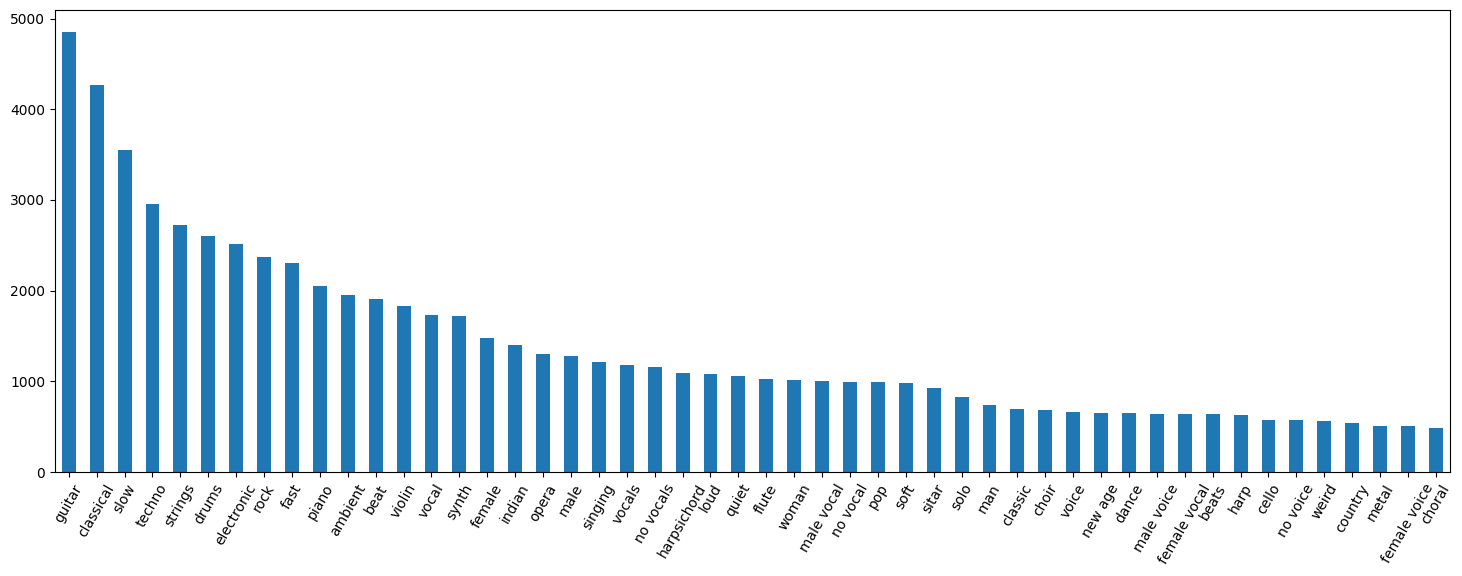

In [3]:
df = pd.read_csv("./annotations_final.csv", sep="\t", index_col=0)
# filter out, un-annnotated dataset
df_filter =  df[TAGS].sum(axis=1)
use_id = df_filter[df_filter != 0].index
df = df.loc[use_id]
df[TAGS].sum().plot.bar(figsize=(18,6),rot=60) # check data distribution

In [4]:
# use 50 top tags
TAGS_SAME = {
    'female': ['female', 'female vocal', 'woman', 'female voice', ],
    'male': ['male', 'male vocal', 'male voice', 'man', ],
    'vocal': ['vocal', 'vocals', 'voice', 'singing',],
    'no vocal': ['no vocals', 'no vocal', 'no voice'],
    'classic': ['classic', 'classical', ],
    }
TAGS_INCLUDE = {
    'female': ['female'] + TAGS_SAME['vocal'],
    'male': ['female'] + TAGS_SAME['vocal'],
    'violin': ['violin', 'strings'],
    'cello': ['cello', 'strings'],
    'harp': ['harp', 'harpsichord', 'strings'],
    'opera': ['opera'] + TAGS_SAME['classic'],
    'choir': ['choir'] + TAGS_SAME['vocal'] + TAGS_SAME['classic']
}

# ['guitar', 'slow','techno','drums','electronic','rock',
# 'fast','piano','ambient','beat','synth','indian',
# 'loud','quiet',
# 'flute', 'pop', 'soft', 'sitar', 'solo',
# 'new age', 'dance', 
# 'beats', 'weird', 'country',
# 'metal', 'choral']

## Check the Same TAGS

In [ ]:
from collections import defaultdict
from tqdm import tqdm

# Count the number of items, that doesn't include whole tags that have the same meaning, using TAGS_SAME
def count_items_that_does_not_include_same(df):
    count_all_dict = defaultdict(int)
    count_wrong_dict = defaultdict(int)
    for i in tqdm(range(len(df))):
        item = df.iloc[i]
        cur_tags = list(item[item == 1].index)
        for category, sim_tags in TAGS_SAME.items():
            if any(tag in cur_tags for tag in sim_tags):
                count_all_dict[category] += 1
                if not set(sim_tags).issubset(set(cur_tags)):
                    count_wrong_dict[category] += 1
    return count_wrong_dict

count_items_that_does_not_include_same(df)

100%|██████████| 21111/21111 [00:03<00:00, 5698.13it/s]


(defaultdict(int,
             {'classic': 4356,
              'female': 1969,
              'vocal': 3155,
              'male': 2026,
              'no vocal': 2186}),
 defaultdict(int,
             {'classic': 3749,
              'female': 1828,
              'vocal': 3089,
              'male': 1866,
              'no vocal': 2134}))

In [ ]:
UPDATE_SAME_FN = "./annotations_updated_same.csv"

def update_the_same_tags(df, fn = UPDATE_SAME_FN):
    if os.path.exists(fn):
        df = pd.read_csv(fn, sep="\t", index_col=0)
        return df
    
    for i in tqdm(range(len(df))):
        item = df.iloc[i]
        cur_tags = list(item[item == 1].index)
        for same_tags in TAGS_SAME.values():
            if any(tag in cur_tags for tag in same_tags):
                for tag in same_tags:
                    df.loc[df.index[i], tag] = 1
    
    check_wrong_dict = count_items_that_does_not_include_same(df)
    assert len(check_wrong_dict) == 0, f"result dict: {check_wrong_dict}"
    
    df.to_csv(fn, sep="\t")
    return df

df_updated = update_the_same_tags(df)

## Check the Including Tags

In [9]:
from collections import defaultdict
from tqdm import tqdm

def count_items_that_does_not_include_inclusive(df):
    count_wrong_dict = defaultdict(int)
    for i in tqdm(range(len(df))):
        item = df.iloc[i]
        cur_tags = list(item[item == 1].index)
        for category, related_tags in TAGS_INCLUDE.items():
            if category in cur_tags:
                if not set(related_tags).issubset(set(cur_tags)):
                    count_wrong_dict[category] += 1
    return count_wrong_dict

count_items_that_does_not_include_inclusive(df)

100%|██████████| 21111/21111 [00:03<00:00, 5924.62it/s]


defaultdict(int,
            {'opera': 1264,
             'violin': 687,
             'female': 1446,
             'male': 1278,
             'choir': 688,
             'cello': 188,
             'harp': 538})

In [11]:
UPDATE_INCLUDE_FN = './annotations_updated_includings.csv'
def update_included_tags(df, fn = UPDATE_INCLUDE_FN):
    if os.path.exists(fn):
        df = pd.read_csv(fn, sep="\t", index_col=0)
        return df
    
    for i in tqdm(range(len(df))):
        item = df.iloc[i]
        cur_tags = list(item[item == 1].index)
        for representative, tags_to_include in TAGS_INCLUDE.items():
            if representative in cur_tags:
                for tag in tags_to_include:
                    df.loc[df.index[i], tag] = 1
                    
    check_wrong_dict = count_items_that_does_not_include_inclusive(df)
    assert len(check_wrong_dict) == 0, f"result dict: {check_wrong_dict}"
    
    df.to_csv(fn, sep="\t")
    return df

df_updated = update_included_tags(df_updated)

100%|██████████| 21111/21111 [00:03<00:00, 5886.64it/s]


<Axes: >

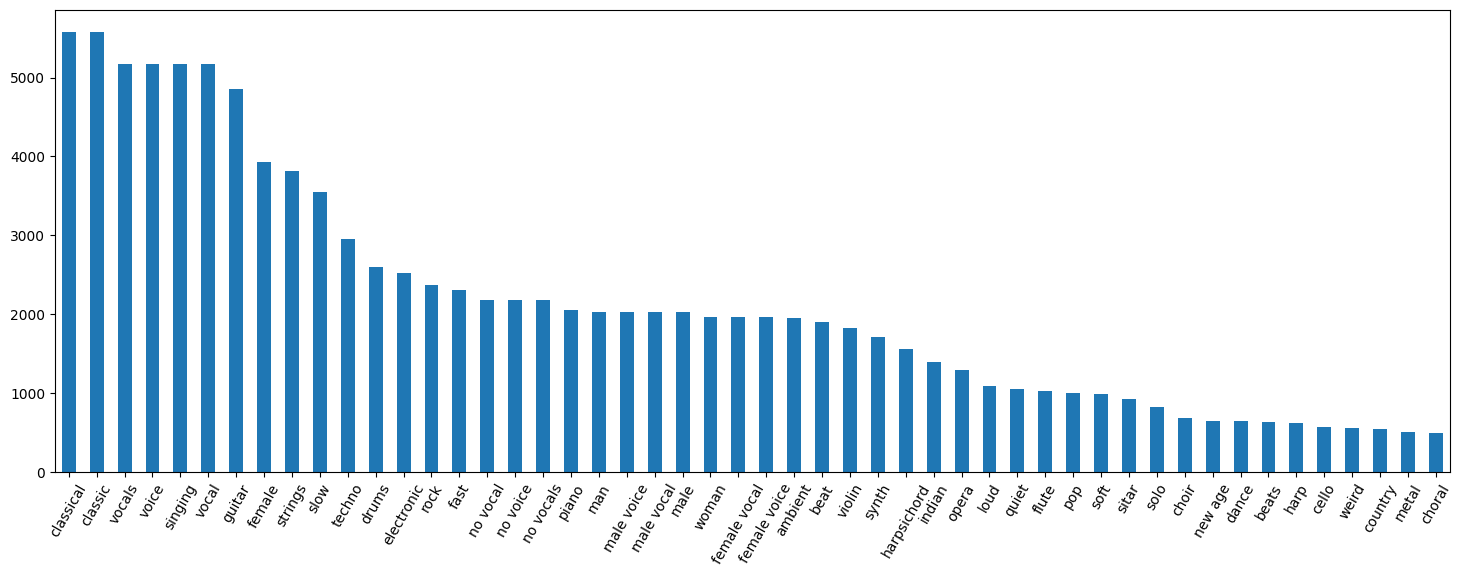

In [14]:
# plot the result again

df_updated[TAGS].sum().sort_values(ascending=False).plot.bar(figsize=(18,6), rot=60) # check data distribution in descending order